Adınız: Melek
Soyadınız: ÇATAL
Okul Numaranız: 2212721039
GitHub Repo Bağlantısı: https://github.com/melekcatal/CNN_Siniflandirma.git

# Model 3 – Model 2’nin Geliştirilmesi (Hiperparametre Optimizasyonu + Augmentation)

Bu aşamada Model-2 temel alınarak en az 3 hiperparametre değiştirilmiş ve
ImageDataGenerator ile online veri artırımı uygulanmıştır.
5 farklı deney yapılarak test doğrulukları karşılaştırılmış ve sonuçlar tablo halinde sunulmuştur.


# Model 3 – Deney 1 (Hiperparametre Geliştirme + Veri Artırımı)

Bu deneyde Model 2 temel alınarak CNN mimarisi geliştirilmiştir.
Aşağıdaki değişiklikler yapılmıştır:
- Filtre sayıları artırılmıştır (16–32–64 → 32–64–128)
- Batch size artırılmıştır (16 → 32)
- Dropout oranı artırılmıştır (0.3 → 0.4)
- ImageDataGenerator kullanılarak online veri artırımı uygulanmıştır

Amaç, Model 2’ye kıyasla daha yüksek test doğruluğu elde etmektir.


In [1]:
# ============================
# MODEL 3 – DENEY 1
# ============================

# Google Drive bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# Gerekli kütüphaneler
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Veri seti yolları
train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'

# Ortak parametreler
Img_Size   = 128
Batch_Size = 32      # 16'dan 32 yapıldı
Epochs     = 15

# ImageDataGenerator (sadece ölçekleme)
train_datagen = ImageDataGenerator(        # Veri Artırımı
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Verilerin yüklenmesi
train_batches = train_datagen.flow_from_directory(
    train_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_datagen.flow_from_directory(
    test_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)

# Sınıf etiketleri
class_labels = list(train_batches.class_indices.keys())
print("Sınıf etiketleri:", class_labels)

# Model oluşturma
model = Sequential()

# filtre sayısı 16–32–64 → 32–64–128 yapıldı

model.add(Conv2D(32, kernel_size=2, padding='same',
                 activation='relu', input_shape=(Img_Size, Img_Size, 3)))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=2, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(128, kernel_size=2, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))                  # 0.3'ten 0.4 yapıldı
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Model derleme
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# En iyi modeli kaydet
checkpointer = ModelCheckpoint(
    filepath='model2_best.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False
)

# Model eğitimi
history = model.fit(
    train_batches,
    epochs=Epochs,
    validation_data=valid_batches,
    callbacks=[checkpointer],
    verbose=1
)


Mounted at /content/drive
Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Sınıf etiketleri: ['fare_disi', 'kelebek']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,236,129 (16.16 MB)

 Trainable params: 4,236,129 (16.16 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.4246 - loss: 0.9020
Epoch 1: val_loss improved from inf to 0.71767, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 43s 11s/step - accuracy: 0.4218 - loss: 0.9134 - val_accuracy: 0.5000 - val_loss: 0.7177
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5971 - loss: 0.6820
Epoch 2: val_loss improved from 0.71767 to 0.69365, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5866 - loss: 0.6819 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5140 - loss: 0.6870
Epoch 3: val_loss improved from 0.69365 to 0.67259, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5129 - loss: 0.6865 - val_accuracy: 0.5833 - val_loss: 0.6726
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6062 - loss: 0.6482
Epoch 4: val_loss improved from 0.67259 to 0.65729, saving model to model2_best.kera

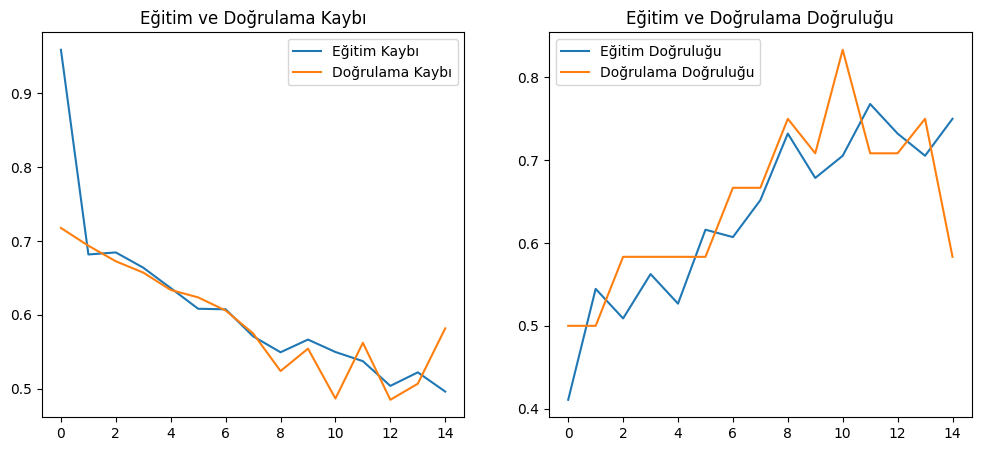

In [2]:
# Eğitim grafikleri
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.legend()
plt.title('Eğitim ve Doğrulama Kaybı')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.legend()
plt.title('Eğitim ve Doğrulama Doğruluğu')

plt.show()

In [3]:
# Test değerlendirmesi
test_score = model.evaluate(test_batches, verbose=1)
print("Test doğruluğu:", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 950ms/step - accuracy: 0.7083 - loss: 0.5592
Test doğruluğu: 0.7083333134651184


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 974ms/step


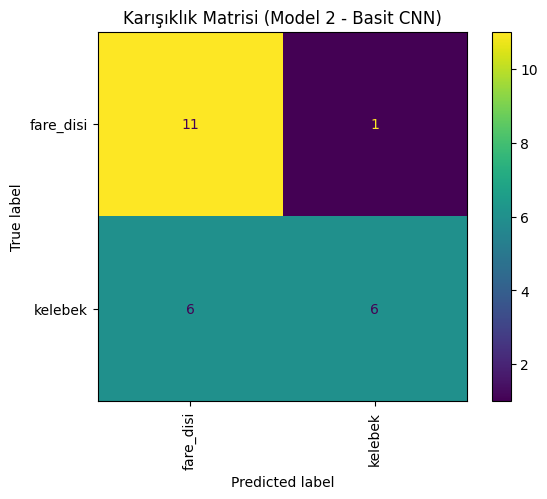

In [4]:
# Confusion Matrix
y_pred = model.predict(test_batches)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_batches.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation='vertical')
plt.title("Karışıklık Matrisi (Model 2 - Basit CNN)")
plt.show()

# Model 3 – Deney 2 (Learning Rate Düşürme)

Bu deneyde Deney 1’de elde edilen mimari korunmuş,
yalnızca öğrenme oranı düşürülerek (0.001 → 0.0005)
daha kararlı bir öğrenme süreci hedeflenmiştir. Kernel size 2 -> 3 yapıldı. Böylece daha geniş bir alanı görür.

In [6]:
# ============================
# MODEL 3 – DENEY 2
# ============================

# Google Drive bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# Gerekli kütüphaneler
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Veri seti yolları
train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'

# Ortak parametreler
Img_Size   = 128
Batch_Size = 32      # 16'dan 32 yapıldı
Epochs     = 15

# ImageDataGenerator (sadece ölçekleme)
train_datagen = ImageDataGenerator(        # Veri Artırımı
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Verilerin yüklenmesi
train_batches = train_datagen.flow_from_directory(
    train_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_datagen.flow_from_directory(
    test_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)

# Sınıf etiketleri
class_labels = list(train_batches.class_indices.keys())
print("Sınıf etiketleri:", class_labels)

# Model oluşturma
model = Sequential()

# filtre sayısı 16–32–64 → 32–64–128 yapıldı

model.add(Conv2D(32, kernel_size=3, padding='same',
                 activation='relu', input_shape=(Img_Size, Img_Size, 3)))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))                  # 0.3'ten 0.4 yapıldı
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Model derleme
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),   # 0.001'den 0.0005 yapıldı.
    metrics=['accuracy']
)

# En iyi modeli kaydet
checkpointer = ModelCheckpoint(
    filepath='model2_best.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False
)

# Model eğitimi
history = model.fit(
    train_batches,
    epochs=Epochs,
    validation_data=valid_batches,
    callbacks=[checkpointer],
    verbose=1
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Sınıf etiketleri: ['fare_disi', 'kelebek']


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5132 - loss: 0.7589
Epoch 1: val_loss improved from inf to 0.74714, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.5123 - loss: 0.7631 - val_accuracy: 0.5000 - val_loss: 0.7471
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5319 - loss: 0.6950
Epoch 2: val_loss improved from 0.74714 to 0.69590, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5398 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6959
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5083 - loss: 0.6930
Epoch 3: val_loss improved from 0.69590 to 0.68072, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5067 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6807
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5281 - loss: 0.6616
Epoch 4: val_loss improved from 0.68072 to 0.65916, saving model to model2_best.ker

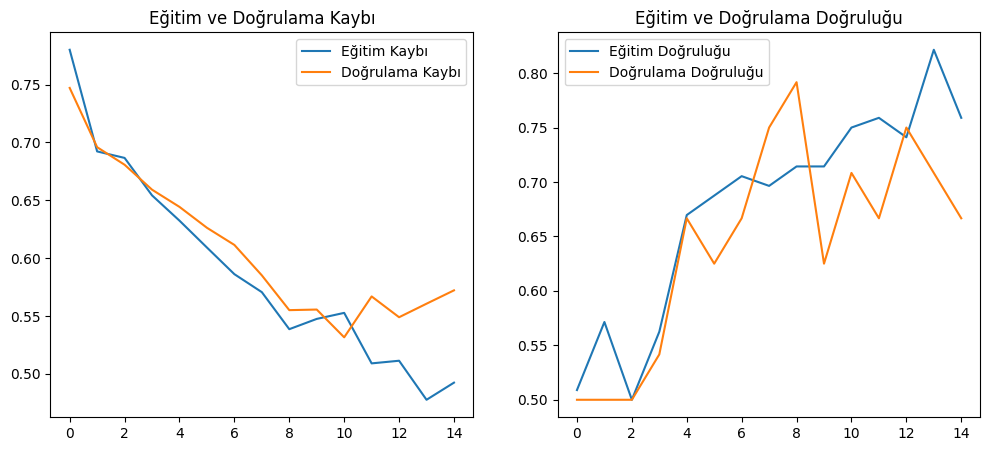

In [7]:
# Eğitim grafikleri
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.legend()
plt.title('Eğitim ve Doğrulama Kaybı')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.legend()
plt.title('Eğitim ve Doğrulama Doğruluğu')

plt.show()

In [8]:
# Test değerlendirmesi
test_score = model.evaluate(test_batches, verbose=1)
print("Test doğruluğu:", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8333 - loss: 0.4317
Test doğruluğu: 0.8333333134651184


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


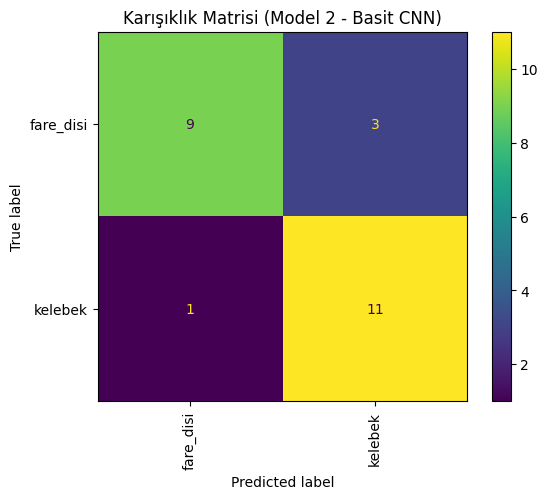

In [9]:
# Confusion Matrix
y_pred = model.predict(test_batches)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_batches.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation='vertical')
plt.title("Karışıklık Matrisi (Model 2 - Basit CNN)")
plt.show()

# Model 3 – Deney 3 (Ek Convolution Katmanı)

Bu deneyde Deney 2’de kullanılan mimari korunmuş,
ancak model kapasitesini artırmak amacıyla
ek bir Convolutional katman eklenmiştir.
Yeni eklenen bu katmanda 256 filtre kullanılarak
daha karmaşık ve yüksek seviyeli özelliklerin
öğrenilmesi hedeflenmiştir.

Dropout değeri 0.4 -> 0.5 yapıldı.


In [10]:
# ============================
# MODEL 3 – DENEY 3
# ============================

# Google Drive bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# Gerekli kütüphaneler
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Veri seti yolları
train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'

# Ortak parametreler
Img_Size   = 128
Batch_Size = 32      # 16'dan 32 yapıldı
Epochs     = 15

# ImageDataGenerator (sadece ölçekleme)
train_datagen = ImageDataGenerator(        # Veri Artırımı
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Verilerin yüklenmesi
train_batches = train_datagen.flow_from_directory(
    train_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_datagen.flow_from_directory(
    test_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)

# Sınıf etiketleri
class_labels = list(train_batches.class_indices.keys())
print("Sınıf etiketleri:", class_labels)

# Model oluşturma
model = Sequential()

# filtre sayısı 16–32–64 → 32–64–128 yapıldı

model.add(Conv2D(32, kernel_size=3, padding='same',
                 activation='relu', input_shape=(Img_Size, Img_Size, 3)))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

# EK CONV KATMANI (256)
model.add(Conv2D(256, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))                  # 0.4'ten 0.5 yapıldı
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Model derleme
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),   # 0.001'den 0.0005 yapıldı.
    metrics=['accuracy']
)

# En iyi modeli kaydet
checkpointer = ModelCheckpoint(
    filepath='model2_best.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False
)

# Model eğitimi
history = model.fit(
    train_batches,
    epochs=Epochs,
    validation_data=valid_batches,
    callbacks=[checkpointer],
    verbose=1
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Sınıf etiketleri: ['fare_disi', 'kelebek']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,485,825 (9.48 MB)

 Trainable params: 2,485,825 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4842 - loss: 0.7647
Epoch 1: val_loss improved from inf to 0.71544, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.4856 - loss: 0.7661 - val_accuracy: 0.5000 - val_loss: 0.7154
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5323 - loss: 0.6827
Epoch 2: val_loss improved from 0.71544 to 0.69210, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.5133 - loss: 0.6874 - val_accuracy: 0.5833 - val_loss: 0.6921
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6146 - loss: 0.6836
Epoch 3: val_loss improved from 0.69210 to 0.68970, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.6042 - loss: 0.6846 - val_accuracy: 0.5417 - val_loss: 0.6897
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5136 - loss: 0.6883
Epoch 4: val_loss improved from 0.68970 to 0.68505, saving model to model2_best.ker

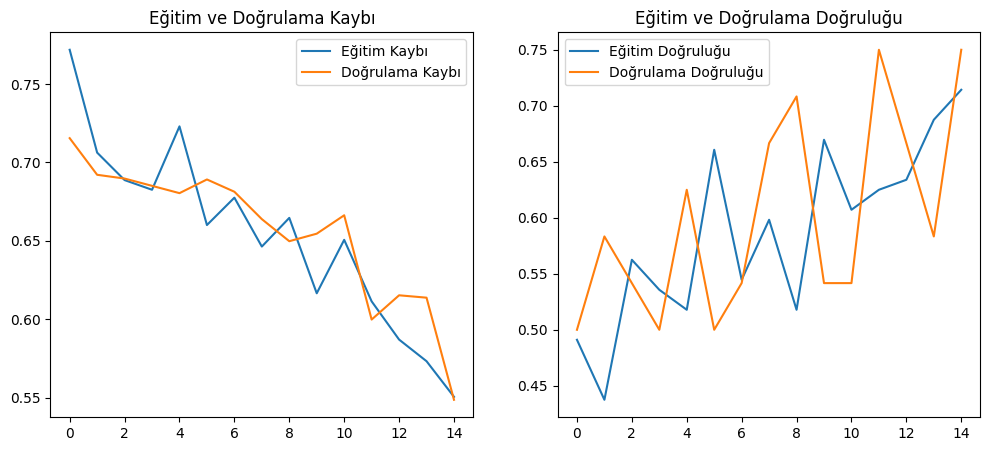

In [11]:
# Eğitim grafikleri
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.legend()
plt.title('Eğitim ve Doğrulama Kaybı')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.legend()
plt.title('Eğitim ve Doğrulama Doğruluğu')

plt.show()

In [12]:
# Test değerlendirmesi
test_score = model.evaluate(test_batches, verbose=1)
print("Test doğruluğu:", test_score[1])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7917 - loss: 0.5418
Test doğruluğu: 0.7916666865348816


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


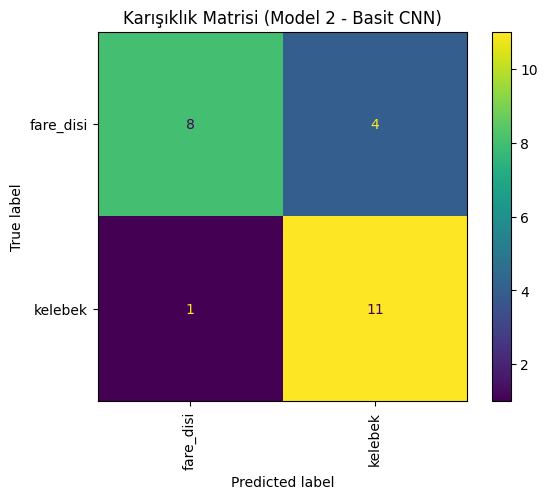

In [13]:
# Confusion Matrix
y_pred = model.predict(test_batches)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_batches.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation='vertical')
plt.title("Karışıklık Matrisi (Model 2 - Basit CNN)")
plt.show()

# Model 3 – Deney 4

Deney 4’te epoch sayısı artırılmış, learning rate daha da düşürülmüş ve veri artırımı
daha kontrollü hale getirilmiş, böylece Deney 2 seviyesinde bir genelleme başarımı
yeniden elde edilmiştir.

In [16]:
# ============================
# MODEL 3 – DENEY 4
# ============================

# Google Drive bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# Gerekli kütüphaneler
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Veri seti yolları
train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'

# Ortak parametreler
Img_Size   = 128
Batch_Size = 32      # 16'dan 32 yapıldı
Epochs     = 20      # 15 -> 20 yapıldı

# ImageDataGenerator (sadece ölçekleme)
train_datagen = ImageDataGenerator(        # Veri Artırımı
    rescale=1./255,
    rotation_range=10,  # 15'ten 10 yapıldı
    width_shift_range=0.1,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Verilerin yüklenmesi
train_batches = train_datagen.flow_from_directory(
    train_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_datagen.flow_from_directory(
    test_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)

# Sınıf etiketleri
class_labels = list(train_batches.class_indices.keys())
print("Sınıf etiketleri:", class_labels)

# Model oluşturma
model = Sequential()

# filtre sayısı 16–32–64 → 32–64–128 yapıldı

model.add(Conv2D(32, kernel_size=3, padding='same',
                 activation='relu', input_shape=(Img_Size, Img_Size, 3)))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

# EK CONV KATMANI (256)
model.add(Conv2D(256, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))                  # 0.4'ten 0.5 yapıldı
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Model derleme
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0003),   # 0.0005'den 0.0003 yapıldı.
    metrics=['accuracy']
)

# En iyi modeli kaydet
checkpointer = ModelCheckpoint(
    filepath='model2_best.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False
)

# Model eğitimi
history = model.fit(
    train_batches,
    epochs=Epochs,
    validation_data=valid_batches,
    callbacks=[checkpointer],
    verbose=1
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Sınıf etiketleri: ['fare_disi', 'kelebek']


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,485,825 (9.48 MB)

 Trainable params: 2,485,825 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5522 - loss: 0.7037
Epoch 1: val_loss improved from inf to 0.68573, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5436 - loss: 0.7039 - val_accuracy: 0.6250 - val_loss: 0.6857
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5324 - loss: 0.6839
Epoch 2: val_loss improved from 0.68573 to 0.68330, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5330 - loss: 0.6850 - val_accuracy: 0.5417 - val_loss: 0.6833
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4924 - loss: 0.6929
Epoch 3: val_loss improved from 0.68330 to 0.68287, saving model to model2_best.keras
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.5029 - loss: 0.6911 - val_accuracy: 0.5417 - val_loss: 0.6829
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6125 - loss: 0.6643
Epoch 4: val_loss improved from 0.68287 to 0.67123, saving model to model2_best.kera

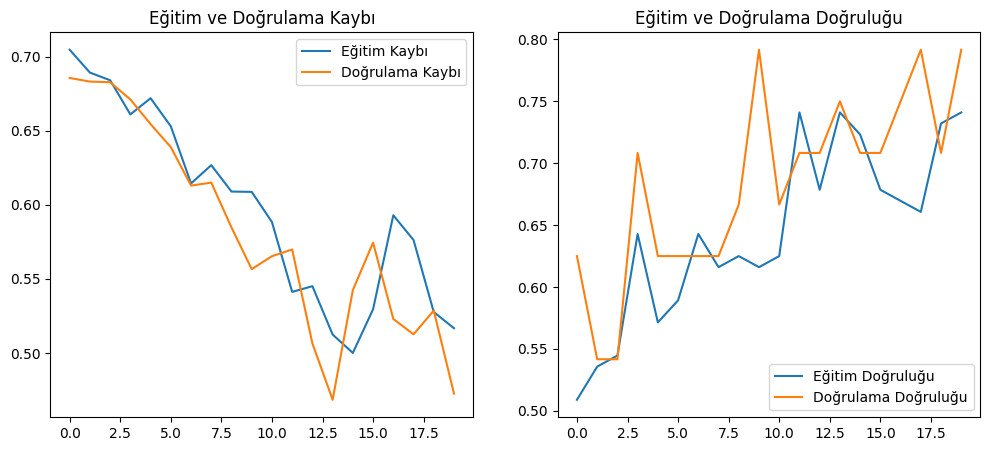

In [17]:
# Eğitim grafikleri
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.legend()
plt.title('Eğitim ve Doğrulama Kaybı')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.legend()
plt.title('Eğitim ve Doğrulama Doğruluğu')

plt.show()

In [18]:
# Test değerlendirmesi
test_score = model.evaluate(test_batches, verbose=1)
print("Test doğruluğu:", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.8333 - loss: 0.4901
Test doğruluğu: 0.8333333134651184


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


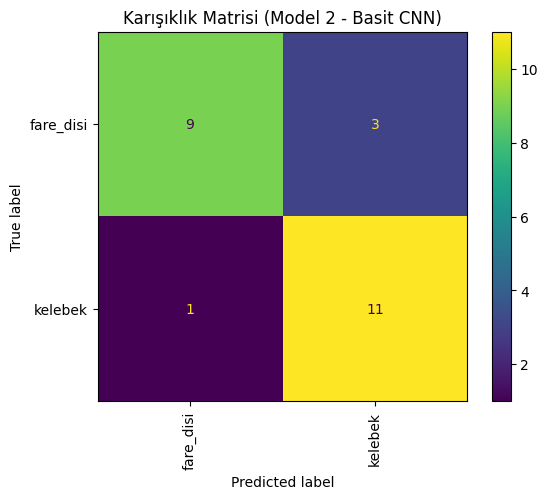

In [19]:
# Confusion Matrix
y_pred = model.predict(test_batches)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_batches.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation='vertical')
plt.title("Karışıklık Matrisi (Model 2 - Basit CNN)")
plt.show()

# Model 3 – Deney 5

Bu deneyde Deney 4’te kullanılan mimari korunmuş,
ancak batch size değeri 32’den 64’e çıkarılmış ve
veri artırımı daha agresif hale getirilmiştir
(rotation_range=20).

Amaç, daha büyük batch size ve güçlü veri artırımının
modelin genelleme performansı üzerindeki etkisini
gözlemlemektir.

In [20]:
# ============================
# MODEL 3 – DENEY 5
# ============================

# Google Drive bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# Gerekli kütüphaneler
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Veri seti yolları
train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'

# Ortak parametreler
Img_Size   = 128
Batch_Size = 64      # 32'den 64 yapıldı
Epochs     = 20      # 15 -> 20 yapıldı

# ImageDataGenerator (sadece ölçekleme)
train_datagen = ImageDataGenerator(        # Veri Artırımı
    rescale=1./255,
    rotation_range=20,  # 10'dan 20 yapıldı
    width_shift_range=0.1,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Verilerin yüklenmesi
train_batches = train_datagen.flow_from_directory(
    train_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_datagen.flow_from_directory(
    test_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)

# Sınıf etiketleri
class_labels = list(train_batches.class_indices.keys())
print("Sınıf etiketleri:", class_labels)

# Model oluşturma
model = Sequential()

# filtre sayısı 16–32–64 → 32–64–128 yapıldı

model.add(Conv2D(32, kernel_size=3, padding='same',
                 activation='relu', input_shape=(Img_Size, Img_Size, 3)))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

# EK CONV KATMANI (256)
model.add(Conv2D(256, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))                  # 0.4'ten 0.5 yapıldı
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Model derleme
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0003),   # 0.0005'den 0.0003 yapıldı.
    metrics=['accuracy']
)

# En iyi modeli kaydet
checkpointer = ModelCheckpoint(
    filepath='model2_best.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False
)

# Model eğitimi
history = model.fit(
    train_batches,
    epochs=Epochs,
    validation_data=valid_batches,
    callbacks=[checkpointer],
    verbose=1
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Sınıf etiketleri: ['fare_disi', 'kelebek']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_26 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,485,825 (9.48 MB)

 Trainable params: 2,485,825 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4271 - loss: 0.7039
Epoch 1: val_loss improved from inf to 0.69247, saving model to model2_best.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 6s/step - accuracy: 0.4306 - loss: 0.7049 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5402 - loss: 0.6906
Epoch 2: val_loss did not improve from 0.69247
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5327 - loss: 0.6913 - val_accuracy: 0.5000 - val_loss: 0.6955
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5625 - loss: 0.6783
Epoch 3: val_loss improved from 0.69247 to 0.68798, saving model to model2_best.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 7s/step - accuracy: 0.5625 - loss: 0.6776 - val_accuracy: 0.5000 - val_loss: 0.6880
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5993 - loss: 0.6803
Epoch 4: val_loss improved from 0.68798 to 0.68498, saving model to model2_best.keras
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step

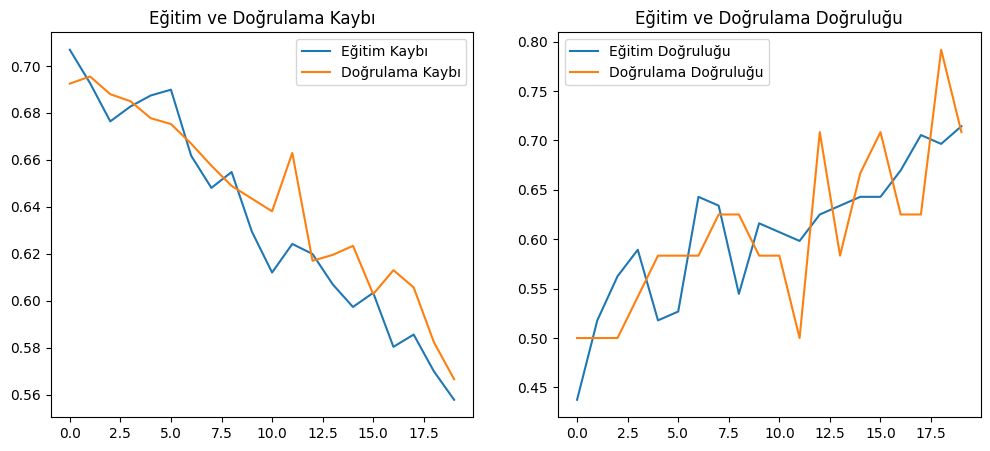

In [21]:
# Eğitim grafikleri
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.legend()
plt.title('Eğitim ve Doğrulama Kaybı')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.legend()
plt.title('Eğitim ve Doğrulama Doğruluğu')

plt.show()

In [22]:
# Test değerlendirmesi
test_score = model.evaluate(test_batches, verbose=1)
print("Test doğruluğu:", test_score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7500 - loss: 0.5374
Test doğruluğu: 0.75


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


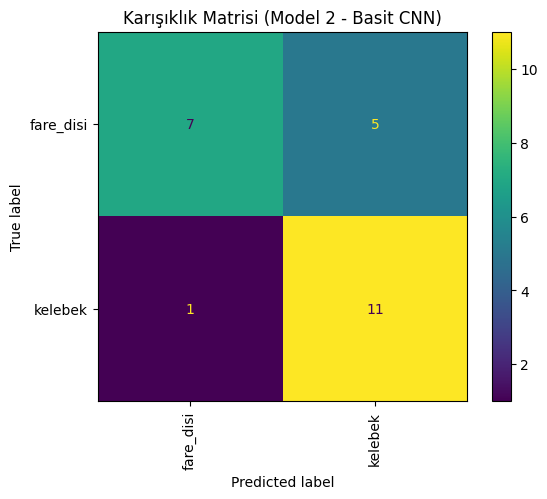

In [23]:
# Confusion Matrix
y_pred = model.predict(test_batches)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_batches.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation='vertical')
plt.title("Karışıklık Matrisi (Model 2 - Basit CNN)")
plt.show()

# Model 3 – Deney 6

Bu deneyde Deney 5 temel alınarak overfitting’i azaltmak
amacıyla Flatten katmanından önce ek bir Dropout katmanı
eklenmiştir. Ayrıca batch size düşürülmüş ve epoch sayısı
artırılarak modelin daha uzun ve dengeli bir şekilde
öğrenmesi hedeflenmiştir.

Bu değişikliklerin, modelin genelleme performansını
iyileştirerek test doğruluğunu artırması amaçlanmıştır.

In [24]:
# ============================
# MODEL 3 – DENEY 6
# ============================

# Google Drive bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# Gerekli kütüphaneler
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Veri seti yolları
train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'

# Ortak parametreler
Img_Size   = 128
Batch_Size = 16
Epochs     = 30      # 20 -> 30 yapıldı

# ImageDataGenerator (sadece ölçekleme)
train_datagen = ImageDataGenerator(        # Veri Artırımı
    rescale=1./255,
    rotation_range=20,  # 10'dan 20 yapıldı
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Verilerin yüklenmesi
train_batches = train_datagen.flow_from_directory(
    train_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_datagen.flow_from_directory(
    test_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)

# Sınıf etiketleri
class_labels = list(train_batches.class_indices.keys())
print("Sınıf etiketleri:", class_labels)

# Model oluşturma
model = Sequential()

# filtre sayısı 16–32–64 → 32–64–128 yapıldı

model.add(Conv2D(32, kernel_size=3, padding='same',
                 activation='relu', input_shape=(Img_Size, Img_Size, 3)))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

# EK CONV KATMANI (256)
model.add(Conv2D(256, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Dropout(0.4)) # Eklenen dropout
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))                  # 0.4'ten 0.5 yapıldı
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Model derleme
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0003),   # 0.0005'den 0.0003 yapıldı.
    metrics=['accuracy']
)

# En iyi modeli kaydet
checkpointer = ModelCheckpoint(
    filepath='model2_best.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False
)

# Model eğitimi
history = model.fit(
    train_batches,
    epochs=Epochs,
    validation_data=valid_batches,
    callbacks=[checkpointer],
    verbose=1
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Sınıf etiketleri: ['fare_disi', 'kelebek']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,485,825 (9.48 MB)

 Trainable params: 2,485,825 (9.48 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3989 - loss: 0.7079
Epoch 1: val_loss improved from inf to 0.69106, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.4048 - loss: 0.7074 - val_accuracy: 0.5417 - val_loss: 0.6911
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5555 - loss: 0.6928
Epoch 2: val_loss improved from 0.69106 to 0.68892, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5564 - loss: 0.6927 - val_accuracy: 0.5833 - val_loss: 0.6889
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5171 - loss: 0.6795
Epoch 3: val_loss improved from 0.68892 to 0.68840, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5172 - loss: 0.6806 - val_accuracy: 0.5000 - val_loss: 0.6884
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4903 - loss: 0.7091
Epoch 4: val_loss improved from 0.68840 to 0.67921, saving model to model2_best.ker

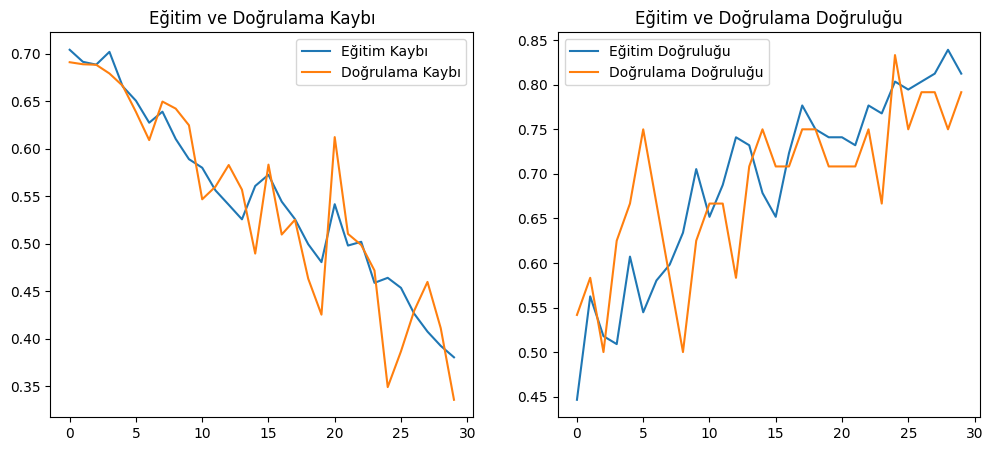

In [25]:
# Eğitim grafikleri
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.legend()
plt.title('Eğitim ve Doğrulama Kaybı')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.legend()
plt.title('Eğitim ve Doğrulama Doğruluğu')

plt.show()

In [26]:
# Test değerlendirmesi
test_score = model.evaluate(test_batches, verbose=1)
print("Test doğruluğu:", test_score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - accuracy: 0.8542 - loss: 0.4269
Test doğruluğu: 0.875


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step


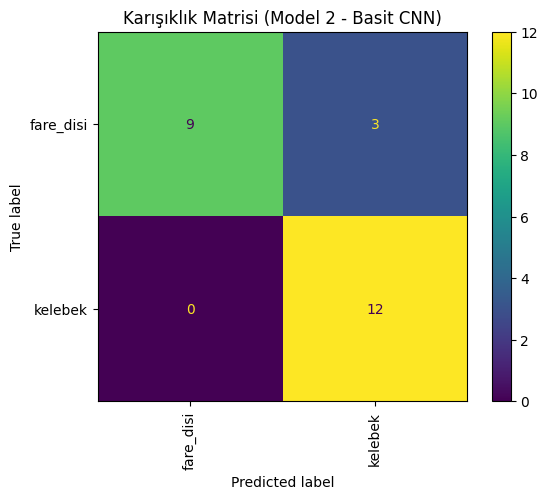

In [27]:
# Confusion Matrix
y_pred = model.predict(test_batches)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_batches.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation='vertical')
plt.title("Karışıklık Matrisi (Model 2 - Basit CNN)")
plt.show()

# Model 3 – Deney 7 (Dense Katman Boyutunun Etkisi)

Bu deneyde Deney 6’daki mimari korunmuş,
ancak tam bağlantılı (Dense) katman boyutu
128’den 500’e çıkarılmıştır.
Amaç, daha geniş bir sınıflandırıcı katmanın
model performansı üzerindeki etkisini incelemektir.


In [36]:
# ============================
# MODEL 3 – DENEY 7
# ============================

# Google Drive bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# Gerekli kütüphaneler
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Veri seti yolları
train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'

# Ortak parametreler
Img_Size   = 128
Batch_Size = 16
Epochs     = 30      # 20 -> 30 yapıldı

# ImageDataGenerator (sadece ölçekleme)
train_datagen = ImageDataGenerator(        # Veri Artırımı
    rescale=1./255,
    rotation_range=20,  # 10'dan 20 yapıldı
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Verilerin yüklenmesi
train_batches = train_datagen.flow_from_directory(
    train_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_datagen.flow_from_directory(
    test_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)

# Sınıf etiketleri
class_labels = list(train_batches.class_indices.keys())
print("Sınıf etiketleri:", class_labels)

# Model oluşturma
model = Sequential()

# filtre sayısı 16–32–64 → 32–64–128 yapıldı

model.add(Conv2D(32, kernel_size=3, padding='same',
                 activation='relu', input_shape=(Img_Size, Img_Size, 3)))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

# EK CONV KATMANI (256)
model.add(Conv2D(256, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Dropout(0.4)) # Eklenen dropout
model.add(Flatten())

model.add(Dense(500, activation='relu'))
model.add(Dropout(0.5))                  # 0.4'ten 0.5 yapıldı
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Model derleme
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0003),   # 0.0005'den 0.0003 yapıldı.
    metrics=['accuracy']
)

# En iyi modeli kaydet
checkpointer = ModelCheckpoint(
    filepath='model2_best.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False
)

# Model eğitimi
history = model.fit(
    train_batches,
    epochs=Epochs,
    validation_data=valid_batches,
    callbacks=[checkpointer],
    verbose=1
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Sınıf etiketleri: ['fare_disi', 'kelebek']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 500)            │     8,192,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,581,417 (32.74 MB)

 Trainable params: 8,581,417 (32.74 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4553 - loss: 0.7204
Epoch 1: val_loss improved from inf to 0.71148, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.4564 - loss: 0.7185 - val_accuracy: 0.5000 - val_loss: 0.7115
Epoch 2/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5285 - loss: 0.7169
Epoch 2: val_loss improved from 0.71148 to 0.68872, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5261 - loss: 0.7170 - val_accuracy: 0.5417 - val_loss: 0.6887
Epoch 3/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4858 - loss: 0.6829
Epoch 3: val_loss improved from 0.68872 to 0.67759, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.4920 - loss: 0.6828 - val_accuracy: 0.5417 - val_loss: 0.6776
Epoch 4/30
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4073 - loss: 0.6770
Epoch 4: val_loss improved from 0.67759 to 0.66886, saving model to model2_best.ker

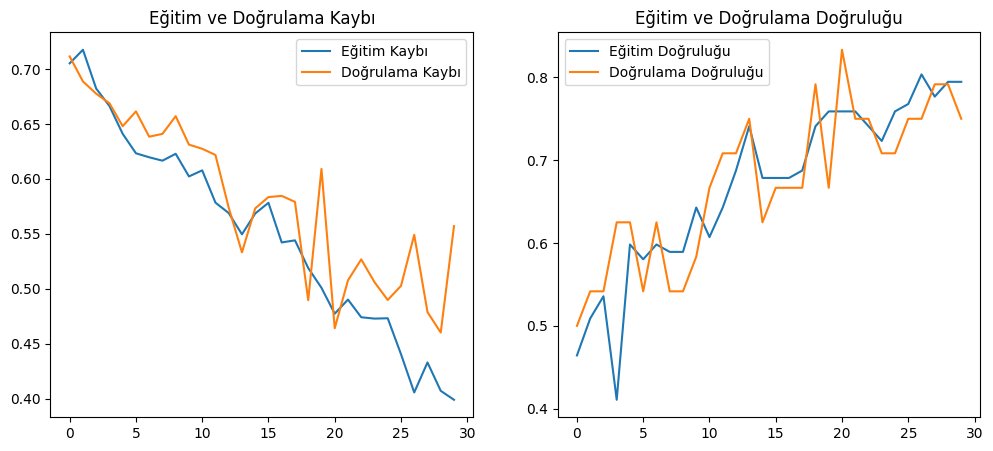

In [37]:
# Eğitim grafikleri
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.legend()
plt.title('Eğitim ve Doğrulama Kaybı')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.legend()
plt.title('Eğitim ve Doğrulama Doğruluğu')

plt.show()

In [38]:
# Test değerlendirmesi
test_score = model.evaluate(test_batches, verbose=1)
print("Test doğruluğu:", test_score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 427ms/step - accuracy: 0.8056 - loss: 0.4744
Test doğruluğu: 0.8333333134651184


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step


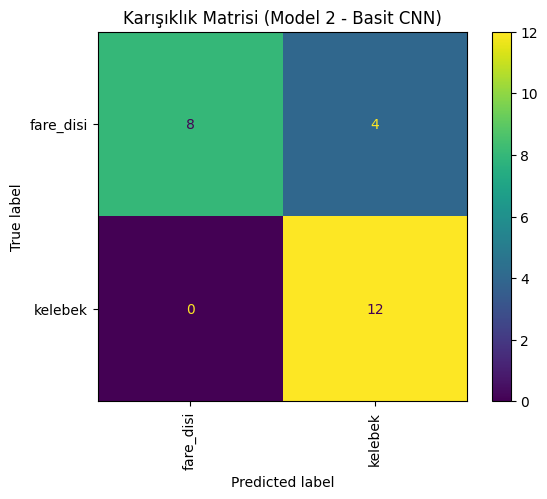

In [39]:
# Confusion Matrix
y_pred = model.predict(test_batches)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_batches.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation='vertical')
plt.title("Karışıklık Matrisi (Model 2 - Basit CNN)")
plt.show()

# Model 3 – Deney 8 (Dense Boyutu ve Düzenleme Dengesi)

Bu deneyde Deney 7’ye kıyasla Dense katman boyutu
500’den 256’ya düşürülmüş ve Flatten öncesi ve
sonrası Dropout oranları yeniden düzenlenmiştir.
Bu ayarlamalarla birlikte, modelin aşırı öğrenmeden
kaçınarak daha iyi genelleme yapması hedeflenmiştir.


In [48]:
# ============================
# MODEL 3 – DENEY 8
# ============================

# Google Drive bağlantısı
from google.colab import drive
drive.mount('/content/drive')

# Gerekli kütüphaneler
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Veri seti yolları
train_path = '/content/drive/MyDrive/Veriseti/train'
valid_path = '/content/drive/MyDrive/Veriseti/val'
test_path  = '/content/drive/MyDrive/Veriseti/test'

# Ortak parametreler
Img_Size   = 128
Batch_Size = 16
Epochs     = 20      #

# ImageDataGenerator (sadece ölçekleme)
train_datagen = ImageDataGenerator(        # Veri Artırımı
    rescale=1./255,
    rotation_range=10,  # 10'dan 20 yapıldı
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Verilerin yüklenmesi
train_batches = train_datagen.flow_from_directory(
    train_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

valid_batches = valid_datagen.flow_from_directory(
    valid_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary'
)

test_batches = test_datagen.flow_from_directory(
    test_path,
    target_size=(Img_Size, Img_Size),
    batch_size=Batch_Size,
    class_mode='binary',
    shuffle=False
)

# Sınıf etiketleri
class_labels = list(train_batches.class_indices.keys())
print("Sınıf etiketleri:", class_labels)

# Model oluşturma
model = Sequential()

# filtre sayısı 16–32–64 → 32–64–128 yapıldı

model.add(Conv2D(32, kernel_size=3, padding='same',
                 activation='relu', input_shape=(Img_Size, Img_Size, 3)))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

# EK CONV KATMANI (256)
model.add(Conv2D(128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Dropout(0.3)) # Eklenen dropout
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))                  # 0.4'ten 0.5 yapıldı
model.add(Dense(1, activation='sigmoid'))

model.summary()

# Model derleme
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0003),   # 0.0005'den 0.0003 yapıldı.
    metrics=['accuracy']
)

# En iyi modeli kaydet
checkpointer = ModelCheckpoint(
    filepath='model2_best.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False
)

# Model eğitimi
history = model.fit(
    train_batches,
    epochs=Epochs,
    validation_data=valid_batches,
    callbacks=[checkpointer],
    verbose=1
)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 112 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Found 24 images belonging to 2 classes.
Sınıf etiketleri: ['fare_disi', 'kelebek']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_54 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_56 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_57 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,338,497 (8.92 MB)

 Trainable params: 2,338,497 (8.92 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4910 - loss: 0.7130
Epoch 1: val_loss improved from inf to 0.69647, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4932 - loss: 0.7128 - val_accuracy: 0.5000 - val_loss: 0.6965
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5467 - loss: 0.6914
Epoch 2: val_loss improved from 0.69647 to 0.69217, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5431 - loss: 0.6919 - val_accuracy: 0.5000 - val_loss: 0.6922
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 976ms/step - accuracy: 0.5182 - loss: 0.6909
Epoch 3: val_loss improved from 0.69217 to 0.68584, saving model to model2_best.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5237 - loss: 0.6904 - val_accuracy: 0.7083 - val_loss: 0.6858
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5513 - loss: 0.6825
Epoch 4: val_loss improved from 0.68584 to 0.67382, saving model to model2_best.k

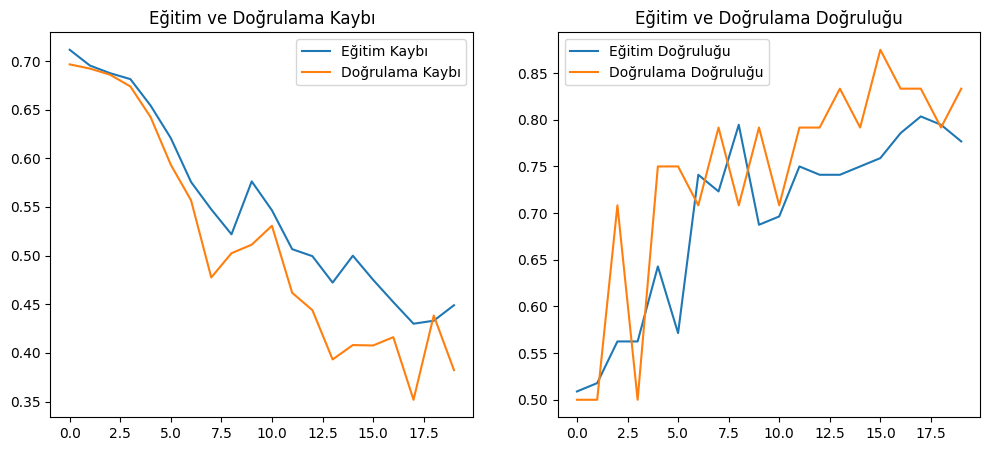

In [49]:
# Eğitim grafikleri
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.legend()
plt.title('Eğitim ve Doğrulama Kaybı')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.legend()
plt.title('Eğitim ve Doğrulama Doğruluğu')

plt.show()

In [50]:
# Test değerlendirmesi
test_score = model.evaluate(test_batches, verbose=1)
print("Test doğruluğu:", test_score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.9236 - loss: 0.3289
Test doğruluğu: 0.9166666865348816


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step


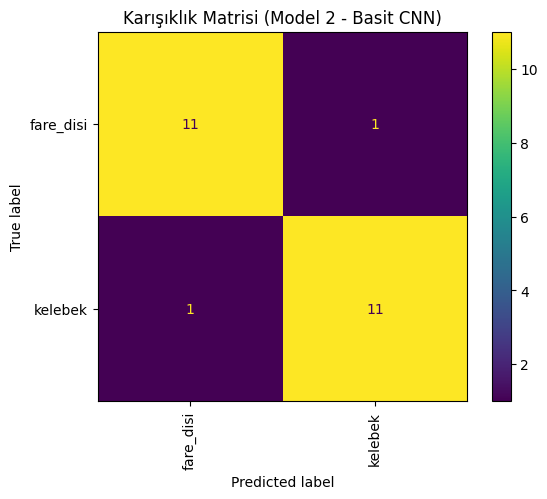

In [51]:
# Confusion Matrix
y_pred = model.predict(test_batches)
y_pred_classes = (y_pred > 0.5).astype(int).ravel()
y_true = test_batches.classes

cm = confusion_matrix(y_true, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(xticks_rotation='vertical')
plt.title("Karışıklık Matrisi (Model 2 - Basit CNN)")
plt.show()

## Genel Sonuç ve Değerlendirme

Bu çalışmada, iki sınıflı görüntü veri seti üzerinde sıfırdan tanımlanmış
bir CNN mimarisi (Model 2) referans alınarak,
hiperparametre ayarlamaları ve mimari değişiklikler içeren
sekiz farklı Model 3 deneyi gerçekleştirilmiştir.

Deneyler sonucunda kernel size ve learning rate parametrelerinin
model performansını en fazla etkileyen faktörler olduğu gözlemlenmiştir.
Kernel size’ın 2’den 3’e çıkarılması ve learning rate’in düşürülmesi,
modelin daha kararlı öğrenmesini sağlayarak test doğruluğunu
belirgin şekilde artırmıştır.

Ayrıca, convolution katman sayısının artırılması tek başına
performans artışı sağlamamış; uygun dropout oranları ve
tam bağlantılı (Dense) katman boyutlarıyla dengelenmediğinde
genelleme performansının düştüğü görülmüştür.
Flatten katmanı öncesinde uygulanan dropout ve daha küçük batch size
kullanımı, aşırı öğrenmeyi azaltarak en yüksek test doğruluğunun
elde edilmesini sağlamıştır.

Sonuç olarak, bu veri seti için en iyi performans,
Model 3 – Deney 8’de elde edilmiş olup,
uygun hiperparametre kombinasyonlarının
model derinliğinden daha kritik olduğu
deneysel olarak gösterilmiştir.


## Deneyler Karşılaştırma Tablosu

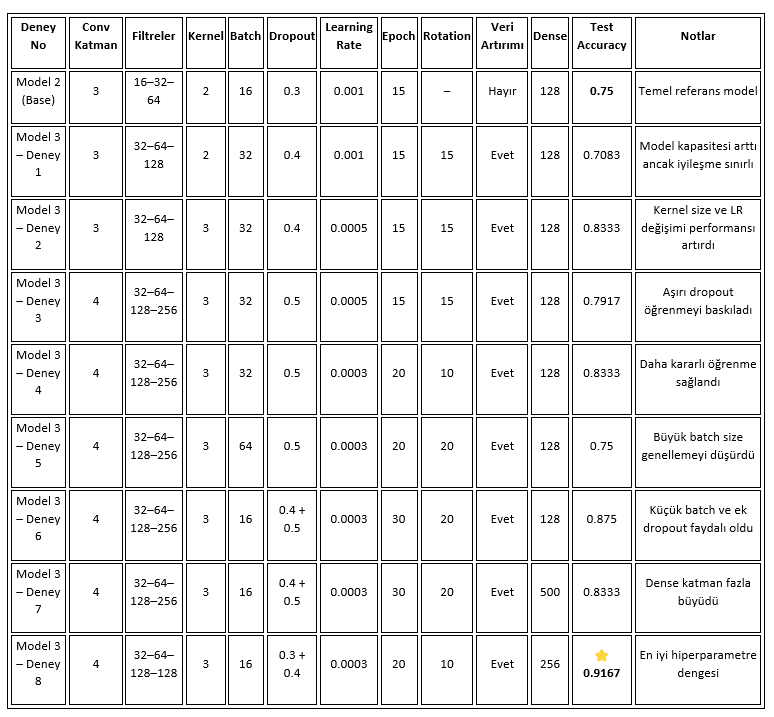